In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import glob
import intake

from dask.distributed import Client
from statsmodels.tsa.seasonal import STL

import matplotlib.pyplot as plt
import cmocean as cm
import cf_xarray
import cftime
import cartopy.crs as ccrs

import xmovie
from xmovie import Movie
print("xmovie version", xmovie.__version__)

import warnings
warnings.filterwarnings(
    action="ignore",
    category=UserWarning,
    message=r"No `(vmin|vmax)` provided. Data limits are calculated from input. Depending on the input this can take long. Pass `\1` to avoid this step"
)

# map_path = "/g/data/ik11/grids/BlueMarble.tiff"
# blue_marble = plt.imread(map_path)
# blue_marble_extent = (-180, 180, -90, 90)

%matplotlib inline

xmovie version 0.3.1


In [2]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 48
Total threads: 48,Total memory: 188.56 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44355,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46403,Total threads: 1
Dashboard: /proxy/46705/status,Memory: 3.93 GiB
Nanny: tcp://127.0.0.1:43213,


In [3]:
catalog = intake.cat.access_nri

In [4]:
# Browse the catalog with, for example:
catalog.search(name='.*01deg_jra55v140_iaf_cycle4.*', variable='temp')

,model,description,realm,frequency,variable
name,,,,,
01deg_jra55v140_iaf_cycle4,{ACCESS-OM2-01},{Cycle 4 of 0.1 degree ACCESS-OM2 global model configuration with JRA55-do v1.4.0 OMIP2 interannual forcing},{ocean},{1mon},{temp}
01deg_jra55v140_iaf_cycle4_jra55v150_extension,{ACCESS-OM2-01},{Extensions of cycle 4 of 0.1 degree ACCESS-OM2 + WOMBAT BGC global model configuration with JRA55-do v1.5.0 and v1.5.0.1 interannual forcing},{ocean},{1mon},{temp}


In [5]:
# Then open a specific experiment with:
catalog['01deg_jra55v140_iaf_cycle4']

,unique
filename,127845
path,131730
file_id,32
frequency,5
start_date,4324
end_date,4324
variable,335
variable_long_name,257
variable_standard_name,37
variable_cell_methods,6


In [6]:
minlon = -240
maxlon = -60
midlon = (minlon + maxlon) / 2

minlat = -5
maxlat = +5
midlat = (minlat + maxlat) / 2

start_time = "1958-01-01 12:00:00"
end_time = "2023-12-31 12:00:00"
time_slice = slice(start_time, end_time)
climatology_baseline = slice("1958", None)

depth_slice = slice(0, 500)
lat_slice = slice(minlat, maxlat)
lon_slice = slice(minlon, maxlon)

time_slice = slice(start_time, end_time)
time_slice

slice('1958-01-01 12:00:00', '2023-12-31 12:00:00', None)

In [7]:
if glob.glob("temp_*.nc") == []:

    def select_region(ds):
        ds = ds.sel({'xt_ocean': lon_slice, 'yt_ocean': lat_slice, 'st_ocean': depth_slice})
        return ds
    
    # the 1958-2018
    ds1 = catalog["01deg_jra55v140_iaf_cycle4"].search(
        variable='temp',
        frequency='1mon'
    ).to_dask(preprocess=select_region)
    
    # 2019-2023
    ds2 = catalog["01deg_jra55v140_iaf_cycle4_jra55v150_extension"].search(
        variable='temp',
        frequency='1mon'
    ).to_dask(preprocess=select_region)
    
    # files = glob("/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf_cycle4_jra55v150_extension/output*/ocean/ocean-3d-temp-1-monthly*.nc")
    # ds2 = xr.open_mfdataset(files, combine="by_coords", decode_timedelta=True, parallel=True)
    # ds2 = select_region(ds2)
    # ds2 = ds2.chunk({"time": 12, "st_ocean": -1, "yt_ocean": -1})
    # ds2 = ds2.drop_vars(["average_T1", "average_T2", "average_DT", "time_bnds", "nv", "st_edges_ocean"])
    # ds2    
    
    for year, ds_year in ds1.groupby('time.year'):
        ds_year.to_netcdf(f'temp_{year}.nc')

    for year, ds_year in ds2.groupby('time.year'):
        ds_year.to_netcdf(f'temp_{year}.nc')

In [8]:
ds = xr.open_mfdataset(
    sorted(glob.glob("temp_*.nc")),
    combine="nested", concat_dim="time",
    data_vars="minimal", coords="minimal", compat="override",
    parallel=True,
)
ds = ds.sortby("time")
ds

<xarray.Dataset> Size: 22GB
Dimensions:   (time: 792, st_ocean: 39, yt_ocean: 100, xt_ocean: 1800)
Coordinates:
  * time      (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2023-12-16T12...
  * st_ocean  (st_ocean) float64 312B 0.5413 1.681 2.94 ... 383.0 423.7 468.4
  * yt_ocean  (yt_ocean) float64 800B -4.944 -4.844 -4.745 ... 4.745 4.844 4.944
  * xt_ocean  (xt_ocean) float64 14kB -239.9 -239.8 -239.7 ... -60.15 -60.05
Data variables:
    temp      (time, st_ocean, yt_ocean, xt_ocean) float32 22GB dask.array<chunksize=(4, 13, 34, 600), meta=np.ndarray>
Attributes: (12/15)
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    intake_esm_vars:                          temp
    intake_esm_attrs:file_id:                 ocean.1mon.nv:2.st_edges_ocean:...
    intake_esm_attrs:frequency:               1mon
    ...                                       ...
    intake_esm_attrs:variable_cell_methods:   ,,,,,,time: mean,,,,
    intake_esm_attrs:variable_units:          days,days since 1900-01-01 00:0...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:temporal_label:          mean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.1mon.nv:2.st_edges_ocean:...

In [8]:
# experiment = "01deg_jra55v140_iaf_cycle4"

# minlon = -220
# maxlon = -80

# lat_slice = slice(-15, 15)
# lon_slice = slice(minlon, maxlon)

# temp = catalog[experiment].search(
#     variable='temp',
#     frequency='1mon'
# ).to_dask()['temp']
# temp = temp.sel(time=slice(start_time, end_time))

# temp = temp.cf.sel(latitude=lat_slice).cf.sel(longitude=lon_slice)
# temp

In [9]:
# sst = catalog[experiment].search(
#     variable='surface_temp',
#     frequency='1mon'
# ).to_dask()['surface_temp']
# sst = sst.sel(time=slice(start_time, end_time))

In [40]:
# sst = temp.isel(st_ocean=0)
# sst = sst.chunk({'yt_ocean': 304, 'xt_ocean': 1400})
# sst = sst.chunk('auto')
# sst.to_netcdf("sst-access-om2-iaf.nc")
# sst

Compute the nino34 index; just for sanity:

In [41]:
# sst = temp.cf.sel(vertical=0, method="nearest")
# nino34_region = sst.cf.sel(latitude=slice(-5, 5), longitude=slice(-170, -120))
# climatology = nino34_region.cf.sel(time=climatology_baseline).groupby('time.month').mean(dim='time')
# sst_anomaly = nino34_region.groupby('time.month') - climatology
# nino34_index = sst_anomaly.cf.mean(dim=['latitude', 'longitude'])
# nino34_index = nino34_index.rename("nino34")
# nino34_index.persist()
# nino34_index.plot()

Compute anomaly based on climatology over `climatology_baseline` period.

In [9]:
temp = ds.temp
temp

<xarray.DataArray 'temp' (time: 792, st_ocean: 39, yt_ocean: 100, xt_ocean: 1800)> Size: 22GB
dask.array<getitem, shape=(792, 39, 100, 1800), dtype=float32, chunksize=(4, 13, 34, 600), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2023-12-16T12...
  * st_ocean  (st_ocean) float64 312B 0.5413 1.681 2.94 ... 383.0 423.7 468.4
  * yt_ocean  (yt_ocean) float64 800B -4.944 -4.844 -4.745 ... 4.745 4.844 4.944
  * xt_ocean  (xt_ocean) float64 14kB -239.9 -239.8 -239.7 ... -60.15 -60.05
Attributes:
    long_name:      Conservative temperature
    units:          K
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_conservative_temperature

In [10]:
climatology_baseline

slice('1958', None, None)

In [11]:
temp_climatology = temp.cf.sel(time=climatology_baseline).groupby('time.month').mean(dim='time')
temp_anomaly = temp.groupby("time.month") - temp_climatology
temp_anomaly = temp_anomaly.rename("temp_anomaly")
temp_anomaly = temp_anomaly.persist()

In [12]:
temp_anomaly = temp_anomaly.chunk(dict(time=-1))
temp_anomaly

<xarray.DataArray 'temp_anomaly' (time: 792, st_ocean: 39, yt_ocean: 100,
                                  xt_ocean: 1800)> Size: 22GB
dask.array<rechunk-merge, shape=(792, 39, 100, 1800), dtype=float32, chunksize=(792, 13, 34, 600), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2023-12-16T12...
    month     (time) int64 6kB dask.array<chunksize=(792,), meta=np.ndarray>
  * st_ocean  (st_ocean) float64 312B 0.5413 1.681 2.94 ... 383.0 423.7 468.4
  * yt_ocean  (yt_ocean) float64 800B -4.944 -4.844 -4.745 ... 4.745 4.844 4.944
  * xt_ocean  (xt_ocean) float64 14kB -239.9 -239.8 -239.7 ... -60.15 -60.05
Attributes:
    long_name:      Conservative temperature
    units:          K
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_conservative_temperature

### Find the temp contour

### Detrending

In [13]:
def detrend1d_check(arr, period):
    res = STL(arr, period = period).fit()
    arr_det = arr - res.trend
    return arr_det

def detrend_separate_check(da, dim, period):
    return xr.apply_ufunc(detrend1d_check, da, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask='parallelized')
    
def detrend1d(arr, order=1):
    arr_det = detrend(arr, order) # order=1 for linear detrending
    return arr_det

def detrend3d(da, dim, order=1):
    # da = da.copy()
    return xr.apply_ufunc(detrend1d,
                          da,
                          input_core_dims=[[dim]],
                          output_core_dims=[[dim]],
                          kwargs=dict(order=order),
                          vectorize=True,
                          dask='parallelized')

def detrend_rolling_window(da, window_size=15):
    pad_size = window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    smoothed_data = padded_data.rolling(time=window_size, center=True).mean('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return da - smoothed_data

# this is linear detrending
# temp_anomaly_detrended = detrend3d(temp_anomaly, dim='time', order=1) 

Pick a point and plot the timeseries for sanity check.

In [14]:
## 

mixed_years = np.array([1908, 1910, 1916, 1917, 1922, 1949, 1995])

CP_years = np.array([1903, 1909, 1924, 1933, 1938, 1942, 1950, 1954,
                     1955, 1964, 1970, 1971, 1973, 1974, 1975, 1984,
                     1988, 1998, 1999, 2000, 2007, 2010, 2011, 2020,
                     2022])

EP_years = np.array([1906, 1962, 1967, 2017, 2021])

neutral_years = np.array([1901, 1907, 1912, 1921, 1923, 1926, 1927,
                          1928, 1929, 1931, 1932, 1934, 1935, 1936,
                          1943, 1944, 1945, 1946, 1947, 1948, 1952,
                          1953, 1958, 1959, 1960, 1978, 1980, 1981,
                          1983, 1989, 1990, 1993, 1996, 2001, 2008,
                          2012, 2013, 2016, 2019])

## After EOF analysis on ACCESS-OM2-01 SST
mixed_years = np.array([1908, 1910, 1916, 1917, 1922, 1949, 1995])

CP_years = np.array([1961, 1964, 1970, 1971, 1973, 1974,
                     1975, 1988, 1995, 1998, 1999, 2000,
                     2007, 2010, 2011])

EP_years = np.array([1966, 1967, 1984, 2017])

neutral_years = np.array([1959, 1960, 1962, 1969, 1977, 1978,
                          1980, 1981, 1983, 1985, 1989, 1990,
                          1993, 1996, 2001, 2003, 2004, 2005,
                          2008, 2012, 2013, 2014, 2016, 2018])

In [15]:
def get_individual_years(val,
                         season=[12, 1, 2],
                         years = np.arange(1960, 1991, 1),
                         standardise=False,
                         anomalies=True):
    """
    standarise = False (don't normalise; we want false for ocean)    
    """

    if anomalies:
        val_seasonal_mean_det = detrend_rolling_window(val.where(val.time.dt.month.isin(season), drop=True).resample(time = 'AS-JUN').mean('time'), #.chunk(dict(time=-1, lat=5, lon=10)),
                                                       window_size = 15)
    else:
        val_seasonal_mean_det = val.where(val.time.dt.month.isin(season), drop=True).resample(time = 'AS-JUN').mean('time')

    if standardise:
        return val_seasonal_mean_det.where(val_seasonal_mean_det.time.dt.year.isin(years), drop=True) / val_seasonal_mean_det.std()
    else:
        return val_seasonal_mean_det.where(val_seasonal_mean_det.time.dt.year.isin(years), drop=True)


In [16]:
# seasons
SON = [ 9, 10, 11]
DJF = [12,  1,  2]
MAM = [ 3,  4,  5]

In [17]:
temp_SON_d20_CP_years = get_individual_years(temp, years=CP_years, season=SON, anomalies=False)
temp_SON_d20_CP_composite = temp_SON_d20_CP_years.mean("time").load()
temp_SON_d20_EP_years = get_individual_years(temp, years=EP_years, season=SON, anomalies=False)
temp_SON_d20_EP_composite = temp_SON_d20_EP_years.mean("time").load()

temp_DJF_d20_CP_years = get_individual_years(temp, years=CP_years, season=DJF, anomalies=False)
temp_DJF_d20_CP_composite = temp_DJF_d20_CP_years.mean("time").load()
temp_DJF_d20_EP_years = get_individual_years(temp, years=EP_years, season=DJF, anomalies=False)
temp_DJF_d20_EP_composite = temp_DJF_d20_EP_years.mean("time").load()

temp_MAM_d20_CP_years = get_individual_years(temp, years=CP_years, season=MAM, anomalies=False)
temp_MAM_d20_CP_composite = temp_MAM_d20_CP_years.mean("time").load()
temp_MAM_d20_EP_years = get_individual_years(temp, years=EP_years, season=MAM, anomalies=False)
temp_MAM_d20_EP_composite = temp_MAM_d20_EP_years.mean("time").load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'AS-JUN' is deprecated and will be removed in a future version, please use 'YS-JUN' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'AS-JUN' is deprecated and will be removed in a future version, please use 'YS-JUN' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'AS-JUN' is deprecated and will be removed in a future version, please use 'YS-JUN' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'AS-JUN' is deprecated and will be removed in a future version, please use 'YS-JUN' instead.
  self.index_grouper = pd.G

In [18]:
temp_SON_CP_years = get_individual_years(temp_anomaly, years=CP_years, season=SON, anomalies=True)
temp_SON_CP_composite = temp_SON_CP_years.mean("time").load()
temp_SON_EP_years = get_individual_years(temp_anomaly, years=EP_years, season=SON, anomalies=True)
temp_SON_EP_composite = temp_SON_EP_years.mean("time").load()

temp_DJF_CP_years = get_individual_years(temp_anomaly, years=CP_years, season=DJF, anomalies=True)
temp_DJF_CP_composite = temp_DJF_CP_years.mean("time").load()
temp_DJF_EP_years = get_individual_years(temp_anomaly, years=EP_years, season=DJF, anomalies=True)
temp_DJF_EP_composite = temp_DJF_EP_years.mean("time").load()

temp_MAM_CP_years = get_individual_years(temp_anomaly, years=CP_years, season=MAM, anomalies=True)
temp_MAM_CP_composite = temp_MAM_CP_years.mean("time").load()
temp_MAM_EP_years = get_individual_years(temp_anomaly, years=EP_years, season=MAM, anomalies=True)
temp_MAM_EP_composite = temp_MAM_EP_years.mean("time").load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'AS-JUN' is deprecated and will be removed in a future version, please use 'YS-JUN' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'AS-JUN' is deprecated and will be removed in a future version, please use 'YS-JUN' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'AS-JUN' is deprecated and will be removed in a future version, please use 'YS-JUN' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'AS-JUN' is deprecated and will be removed in a future version, please use 'YS-JUN' instead.
  self.index_grouper = pd.G

Plot the composites

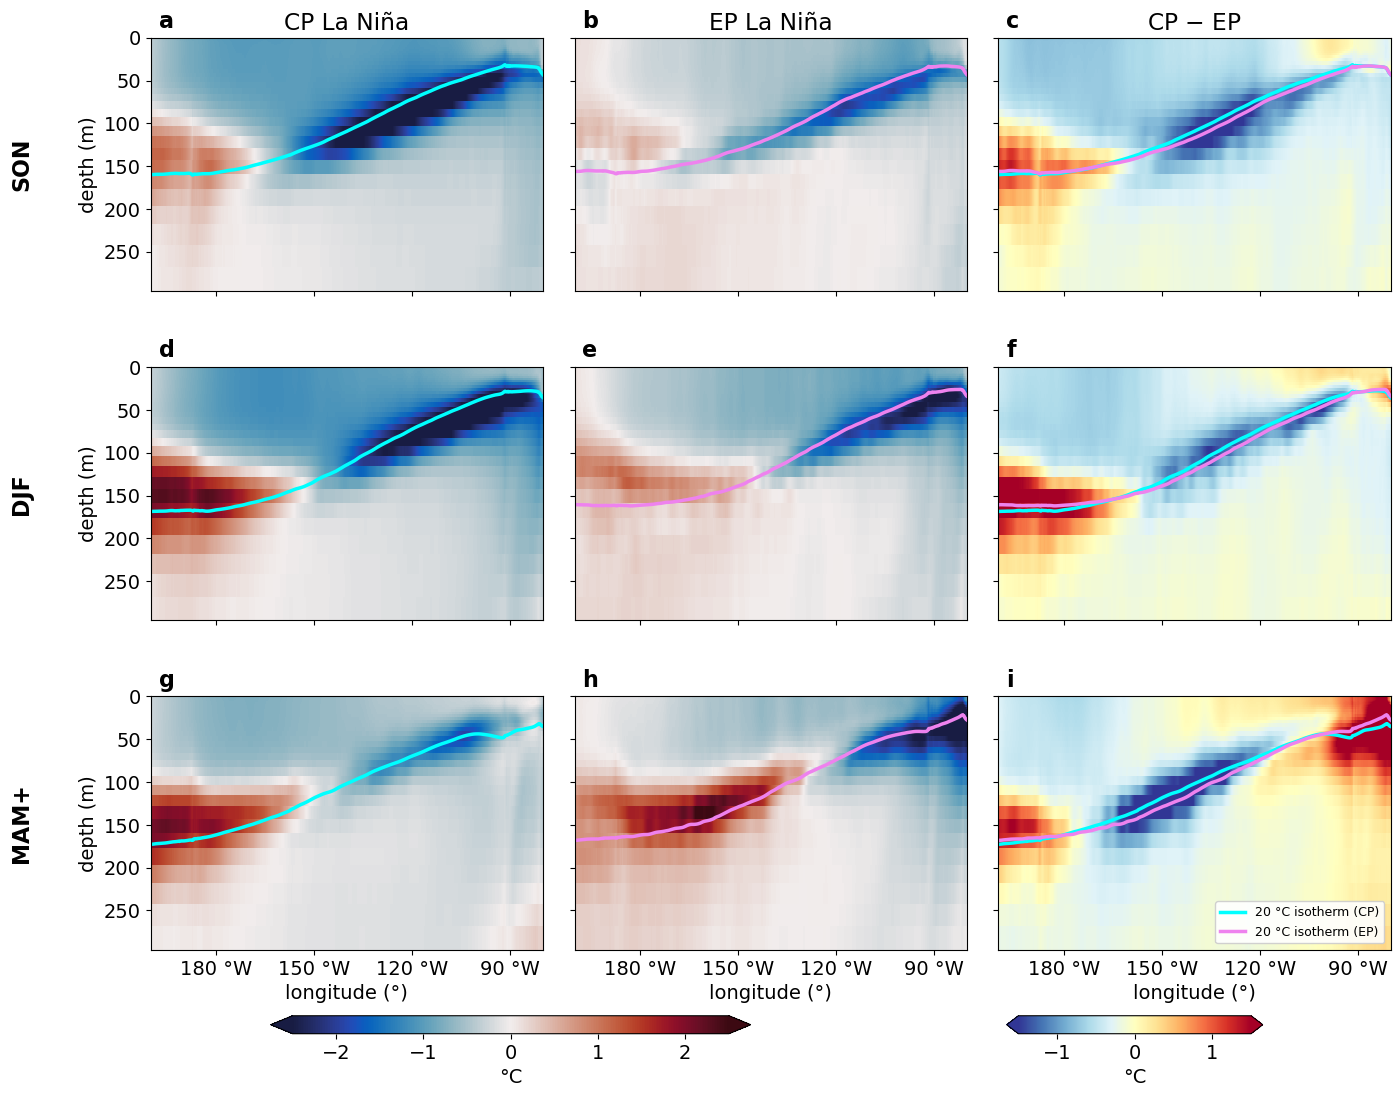

In [19]:
import string
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import cmocean as cm

templim = 2.5
templim_diff = 1.5

cmap      = cm.cm.balance       # anomaly columns (blue–white–red)
cmap_diff = plt.cm.RdYlBu_r     # difference column (blue–yellow–red)
col_CP = "cyan"
col_EP = "violet"

seasons       = ["SON", "DJF", "MAM"]
season_labels = ["SON", "DJF", "MAM+"]
panel_labels  = list(string.ascii_lowercase)


def prep(da):
    """Upper 300 m, longitudes >= -200, meridionally averaged section."""
    return (da.cf.sel(vertical=slice(0, 300))
              .cf.sel(longitude=slice(-200, None))
              .cf.mean("latitude"))


def lon_formatter(x, pos):
    lon = (x + 180) % 360 - 180          # normalise to (-180, 180]
    if np.isclose(lon, 0):
        return "0 °"
    return f"{abs(lon):.0f} °W" if lon < 0 else f"{lon:.0f} °E"


fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.subplots_adjust(wspace=0.08, hspace=0.3, bottom=0.12)

hm_bal = hm_diff = None   # mappables captured for the shared colorbars

for i, s in enumerate(seasons):
    cp     = globals()[f"temp_{s}_CP_composite"]
    ep     = globals()[f"temp_{s}_EP_composite"]
    d20_cp = globals()[f"temp_{s}_d20_CP_composite"]
    d20_ep = globals()[f"temp_{s}_d20_EP_composite"]

    # --- column 0: CP anomaly ---
    ax = axes[i, 0]
    m = prep(cp).plot(ax=ax, vmin=-templim, vmax=+templim, extend="both",
                      cmap=cmap, rasterized=True, add_colorbar=False)
    hm_bal = hm_bal or m
    prep(d20_cp - 273.15).plot.contour(levels=[20.], linewidths=2.5,
                                       ax=ax, colors=col_CP)

    # --- column 1: EP anomaly ---
    ax = axes[i, 1]
    prep(ep).plot(ax=ax, vmin=-templim, vmax=+templim, extend="both",
                  cmap=cmap, rasterized=True, add_colorbar=False)
    prep(d20_ep - 273.15).plot.contour(levels=[20.], linewidths=2.5,
                                       ax=ax, colors=col_EP)

    # --- column 2: CP - EP difference ---
    ax = axes[i, 2]
    m = prep(cp - ep).plot(ax=ax, vmin=-templim_diff, vmax=+templim_diff,
                           extend="both", cmap=cmap_diff, rasterized=True,
                           add_colorbar=False)
    hm_diff = hm_diff or m
    prep(d20_cp - 273.15).plot.contour(levels=[20.], linewidths=2.5,
                                       ax=ax, colors=col_CP)
    prep(d20_ep - 273.15).plot.contour(levels=[20.], linewidths=2.5,
                                       ax=ax, colors=col_EP)

# ---- titles, panel labels, axis cosmetics ----
axes[0, 0].set_title("CP La Niña")
axes[0, 1].set_title("EP La Niña")
axes[0, 2].set_title(r"CP $-$ EP")

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.invert_yaxis()
        ax.set_xlim(-200, -80)
        ax.set_xticks([-180, -150, -120, -90])
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lon_formatter))
        ax.text(0.02, 1.11, panel_labels[i * 3 + j], transform=ax.transAxes,
                fontsize=16, va="top", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
    # bold season label on the left of each row
    axes[i, 0].text(-0.3, 0.5, season_labels[i], transform=axes[i, 0].transAxes,
                    fontsize=16, fontweight="bold", va="center", ha="right",
                    rotation="vertical")

# x tick labels: bottom row only
for ax in axes[2, :]:
    ax.tick_params(labelbottom=True)
    ax.set_xlabel("longitude (°)")
for ax in axes[:2, :].ravel():
    ax.tick_params(labelbottom=False)

# y tick labels + depth label: left column only
for ax in axes[:, 0]:
    ax.tick_params(labelleft=True)
    ax.set_ylabel("depth (m)")
for ax in axes[:, 1:].ravel():
    ax.tick_params(labelleft=False)

# ---- isotherm legend in panel (i) ----
iso_handles = [
    Line2D([0], [0], color=col_CP, lw=2.5, label="20 °C isotherm (CP)"),
    Line2D([0], [0], color=col_EP, lw=2.5, label="20 °C isotherm (EP)"),
]
axes[2, 2].legend(handles=iso_handles, loc="lower right",
                  fontsize=9, framealpha=0.9)

# ---- two shared horizontal colorbars ----
cax_bal  = fig.add_axes([0.20, 0.05, 0.30, 0.015])   # under columns 1–2
cax_diff = fig.add_axes([0.66, 0.05, 0.16, 0.015])   # under column 3
fig.colorbar(hm_bal,  cax=cax_bal,  orientation="horizontal",
             extend="both", label="°C")
fig.colorbar(hm_diff, cax=cax_diff, orientation="horizontal",
             extend="both", label="°C")

plt.savefig("Fig4_ocean-LaNina-CP-EP.pdf", bbox_inches='tight', dpi=300)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

da = temp_CP_composite - temp_EP_composite

da.cf.sel(vertical=slice(0, 300)).cf.sel(longitude=slice(-200, None)).cf.mean("latitude").plot(
    ax=ax,
    vmin=-3.5,
    vmax=+3.5,
    extend="both",
    cmap="RdBu_r",
    cbar_kwargs={"label": "temp anomaly (deg)",
                 "fraction": 0.03,
                 "aspect": 15,
                 "shrink": 0.7},
)

ax.invert_yaxis()

In [ ]:
temp_EP_composite.cf.mean('latitude').plot()

In [ ]:
random_location = {"vertical": 0, "latitude": 1, "longitude": -100}

plt.figure()
temp_anomaly.cf.sel(random_location, method='nearest').plot(label="original")
temp_anomaly_detrended.cf.sel(random_location, method='nearest').plot(label="detrended")
plt.legend()

Average over the latitude range

In [ ]:
temp_anomaly_detrended_latmean = temp_anomaly_detrended.cf.mean("latitude")
temp_anomaly_detrended_latmean

Save as netCDF for quicker load!

In [ ]:
filename = "temp_anomaly_detrended_latmean-" + resolution.replace(".", "p")

if os.path.exists(filename + ".nc"):
    print("The file " + filename + ".nc" + " already exists.")
else:
    print("The file " + filename + ".nc" + " does not exist. Saving it now...")
    temp_anomaly_detrended_latmean.to_netcdf(filename + ".nc")

Load the temperature anomaly (detrended and averaged over latitude range around the equator) from the netCDF file!

In [ ]:
temp_anomaly = xr.open_dataarray(filename + ".nc")
temp_anomaly

In [ ]:
def plot_temp(da, fig, timestamp, *args, **kwargs):

    ax = fig.add_subplot(1, 1, 1)

    da.isel(time=timestamp).plot(
        ax=ax,
        vmin=-3.5,
        vmax=+3.5,
        extend="both",
        cmap="RdBu_r",
        cbar_kwargs={"label": "temp anomaly (deg)",
                     "fraction": 0.03,
                     "aspect": 15,
                     "shrink": 0.7},
    )

    ax.set_title(da['time'].dt.strftime('%d-%m-%Y')[timestamp].item())

    ax.invert_yaxis()
    ax.set_ylabel("depth (m)")
    ax.set_xlabel("longitude (degE)")

    return ax, None

Plot a frame of the movie to check it out.

In [ ]:
fig = plt.figure()

plot_temp(temp_anomaly, fig, 0)

Create a movie object! Chunk the data array to use `parallel=True` when saving the movie.

In [ ]:
fig = plt.figure()

mov = Movie(temp_anomaly.chunk({'time': 1}), plot_temp);

In [ ]:
mov.preview(0)

In [ ]:
mov.save(filename + ".mp4",
         progress=True,
         framerate=3,
         overwrite_existing=True,
         remove_movie=False,
         parallel=True,
         parallel_compute_kwargs=dict(scheduler="processes", num_workers=12)
        )